# Nucleus segmentation to SpatialData zarr

`spatialrefinery.segmentation` segments nuclei in an H&E whole-slide image and packages the result as a [SpatialData](https://spatialdata.scverse.org/en/stable/) zarr store. It is two functions and a `cells.geojson` between them: `segment_wsi` runs [InstanSeg](https://github.com/instanseg/instanseg) over the slide, and `geojson_to_spatialdata` turns its polygons into a zarr carrying the slide image, the nucleus boundaries, and a table annotating them.

InstanSeg owns the whole-slide layer this needs -- tiling, cross-tile label matching, an Otsu tissue prefilter so background is never segmented, and GeoJSON export. The GeoJSON in between is a resume boundary: a failed conversion does not force re-segmentation.

The table the conversion writes is all-zero counts over a template's `var`. Nucleus segmentation produces no expression data, so the table exists to give the shapes element a SpatialData-valid annotation -- and to fix the gene axis that inferred expression will later be written into.

This picks up where {doc}`Converting images to OME-TIFF <convert_to_ometiff>` leaves off: the `.ome.tif` written there is exactly what `segment_wsi` reads. Segmentation needs the optional `segmentation` extra, which pulls `instanseg-torch` and therefore torch's multi-GB CUDA wheels:

```bash
pip install "spatialrefinery[segmentation] @ git+https://github.com/peng-lab/spatialrefinery.git"
```

**What you need:** one TIFF-backed slide (`.ome.tif`, `.svs`, `.ndpi`, ...), a template `.h5ad` whose `var` defines the gene axis, and a CUDA GPU. **Runtime:** on the 867 MB kidney H&E below, 8 minutes for segmentation (1239 tiles) and about a minute to write the zarr; CPU-only is possible but far slower.

In [1]:
from pathlib import Path

import spatialdata as sd
import spatialdata_plot  # noqa: F401 - registers the `.pl` accessor on SpatialData

from spatialrefinery.segmentation.instanseg import segment_wsi
from spatialrefinery.segmentation.to_spatialdata import default_zarr_path, geojson_to_spatialdata

/p/project1/hai_1240/spatialrefinery/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

`SEG_OUTDIR` holds the per-slide segmentation results and `ZARR_OUTDIR` the SpatialData stores. They are kept apart deliberately: the GeoJSON stage is the expensive one, so it is worth preserving independently of any zarr you rebuild from it.

`TEMPLATE_ADATA` is an AnnData whose `var` is the gene panel you intend to infer expression for. Only `var` is read -- `X`, `obs` and everything else are ignored -- so a panel definition saved from any matching study works.

In [2]:
WSI_PATH = Path(
    "/p/project1/hai_spatial_clip/data/phoenix_datasets/panels/multi_tissue/TENX/"
    "Xenium_V1_hKidney_nondiseased_section/Xenium_V1_hKidney_nondiseased_section_he_image.ome.tif"
)
SEG_OUTDIR = Path("/p/scratch/hai_1240/segmentation_files/segmentation_docs")
ZARR_OUTDIR = Path("/p/scratch/hai_1240/segmentation_files")
TEMPLATE_ADATA = Path("/p/scratch/hai_1240/segmentation_files/template_kidney_panel.h5ad")

SEG_OUTDIR.mkdir(parents=True, exist_ok=True)
ZARR_OUTDIR.mkdir(parents=True, exist_ok=True)

## Step 1 -- segment nuclei

`segment_wsi` writes `<outdir>/<slide filename>/cells.geojson`. The directory keeps the *full* filename, extension included, so that `a.svs` and `a.ndpi` cannot land on top of each other. `skip_existing=True` (the default) returns immediately when that file is already there, which makes an interrupted batch resumable.

Two parameters are worth knowing before a first run:

- **`pixel_size`** -- microns per pixel, read from the slide metadata when omitted. InstanSeg rejects anything outside   [0.1, 1] micron, so pass it explicitly for slides whose resolution tags are missing or nonsensical. The slide here   reports 0.2738, so it is left out.
- **`clahe_clip` / `seed_threshold`** -- InstanSeg normalises each tile by percentiles, so on weakly haematoxylin-stained   slides pale nuclei fall below the seed threshold and are missed. Running CLAHE over each tile lifts local contrast   (applied to L in LAB, so the H&E hue balance the model was trained on is preserved), and a lower seed threshold detects   fainter nuclei. On this pale kidney section the two together found 83,554 nuclei against 67,168 at the defaults, +24.4%,   with boundaries that hold up on visual inspection. Both are off by default; the values below are a reasonable start.

`gpu_id` is the CUDA device index, or `None` to force CPU.

In [3]:
geojson_path = segment_wsi(
    WSI_PATH,
    SEG_OUTDIR,
    gpu_id=0,
    clahe_clip=2.0,
    seed_threshold=0.4,
)
geojson_path

INFO     Segmenting Xenium_V1_hKidney_nondiseased_section_he_image.ome.tif with InstanSeg(brightfield_nuclei) on   
         cuda:0                                                                                                    


Model brightfield_nuclei version 0.1.1 already downloaded in /p/project1/hai_1240/spatialrefinery/.venv/lib/python3.12/site-packages/instanseg/utils/../bioimageio_models/, loading


INFO     Applying CLAHE (clip=2.0) to each tile before inference                                                   


Slide progress: 100%|██████████| 1239/1239 [07:07<00:00,  2.90it/s]

Exporting to geojson


100%|██████████| 38/38 [00:42<00:00,  1.11s/it]

INFO     Wrote                                                                                                     
         /p/scratch/hai_1240/segmentation_files/segmentation_docs/Xenium_V1_hKidney_nondiseased_section_he_image.om
         e.tif/cells.geojson                                                                                       


PosixPath('/p/scratch/hai_1240/segmentation_files/segmentation_docs/Xenium_V1_hKidney_nondiseased_section_he_image.ome.tif/cells.geojson')

## Step 2 -- build the SpatialData zarr

`geojson_to_spatialdata` assembles three elements:

- `images["he_image"]` -- a lazy multiscale image built straight from the slide's own pyramid through `tifffile`'s zarr   interface, so dask reads only the blocks a write touches. A level-0 plane on this slide is 33427 x 11949 x 3, about   1.1 GiB if it were materialised.
- `shapes["nucleus_boundaries"]` -- one polygon per nucleus, in pixel coordinates.
- `tables["table"]` -- all-zero counts over `TEMPLATE_ADATA`'s `var`, annotating the shapes, with nucleus centroids in   `obsm["spatial"]`.

`default_zarr_path` gives the store its conventional name: the slide's stem plus `.zarr`, so `Xenium_..._he_image.ome.tif` becomes `Xenium_..._he_image.zarr`. The whole extension goes, which `Path.stem` alone would not do -- it strips only the last suffix and would leave `...he_image.ome`. Note this differs from step 1, whose directory keeps the full filename.

`write_zip=True` (the default) also writes an uncompressed `<name>.zarr.zip` beside the store. A zarr is tens of thousands of small files; the archive is what you actually move between filesystems.

The function also returns the object it just wrote, but its image element is still backed by the slide's own TIFF rather than by the zarr. Read the store back from disk instead, as the next cell does -- that is what any downstream consumer sees.

In [4]:
zarr_path = default_zarr_path(WSI_PATH, ZARR_OUTDIR)
print(zarr_path)

geojson_to_spatialdata(
    geojson_path=geojson_path,
    zarr_path=zarr_path,
    image_path=WSI_PATH,
    template_adata_path=TEMPLATE_ADATA,
)
print(f"wrote {zarr_path.name} and {zarr_path.name}.zip")

/p/scratch/hai_1240/segmentation_files/Xenium_V1_hKidney_nondiseased_section_he_image.zarr
INFO     Exploding multi-polygons from                                                                             
         /p/scratch/hai_1240/segmentation_files/segmentation_docs/Xenium_V1_hKidney_nondiseased_section_he_image.om
         e.tif/cells.geojson                                                                                       


/p/project1/hai_1240/spatialrefinery/.venv/lib/python3.12/site-packages/pyogrio/geopandas.py:948: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


INFO     Reading exploded GeoJSON                                                                                  


INFO     Loading template AnnData: /p/scratch/hai_1240/segmentation_files/template_kidney_panel.h5ad               


INFO     Building SpatialData object (83554 nuclei)                                                                


INFO     Writing SpatialData zarr to                                                                               
         /p/scratch/hai_1240/segmentation_files/Xenium_V1_hKidney_nondiseased_section_he_image.zarr                


/p/project1/hai_1240/spatialrefinery/.venv/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:477: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     Creating uncompressed zip archive                                                                         


wrote Xenium_V1_hKidney_nondiseased_section_he_image.zarr and Xenium_V1_hKidney_nondiseased_section_he_image.zarr.zip


## Inspect the result

Read the store back from disk -- the same thing any downstream consumer sees.

In [5]:
sdata = sd.read_zarr(zarr_path)
print(f"{len(sdata['nucleus_boundaries']):,} nuclei over a {sdata['table'].shape[1]}-gene panel")
sdata

83,554 nuclei over a 377-gene panel


SpatialData object, with associated Zarr store: /p/scratch/hai_1240/segmentation_files/Xenium_V1_hKidney_nondiseased_section_he_image.zarr
├── Images
│     └── 'he_image': DataTree[cyx] (3, 33427, 11949), (3, 16713, 5974), (3, 8356, 2987), (3, 4178, 1493), (3, 2089, 746)
├── Shapes
│     └── 'nucleus_boundaries': GeoDataFrame shape: (83554, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (83554, 377)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), nucleus_boundaries (Shapes)

At full-slide zoom the nuclei are subpixel, so the overlay reads as tissue-shaped coverage: useful for checking that the Otsu prefilter kept to the tissue and did not wander into background.

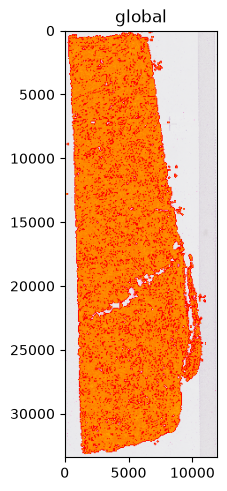

In [6]:
sdata.pl.render_images("he_image").pl.render_shapes(
    "nucleus_boundaries",
    color="yellow",
    fill_alpha=0.7,
    outline_width=1.0,
    outline_alpha=1.0,
    outline_color="red",
).pl.show()

Individual boundaries only become visible on a crop. `query.bounding_box` subsets every element at once, in pixel coordinates on the `"global"` system.

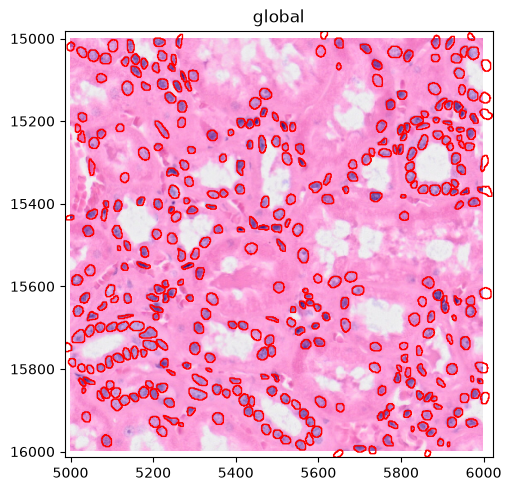

In [7]:
cropped = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[5000, 15000],
    max_coordinate=[6000, 16000],
    target_coordinate_system="global",
)

cropped.pl.render_images("he_image").pl.render_shapes(
    "nucleus_boundaries",
    fill_alpha=0.0,
    outline_width=1.0,
    outline_alpha=1.0,
    outline_color="red",
).pl.show()

## Expected output structure

```text
segmentation_docs/
└── Xenium_V1_hKidney_nondiseased_section_he_image.ome.tif/   # full filename
    └── cells.geojson

Xenium_V1_hKidney_nondiseased_section_he_image.zarr/          # stem only
├── images/he_image/          # multiscale, 5 pyramid levels
├── shapes/nucleus_boundaries/
├── tables/table/
└── zmetadata
Xenium_V1_hKidney_nondiseased_section_he_image.zarr.zip
```

## Batch processing multiple slides

Both stages skip work that is already on disk, so the loop below is safe to re-run over a directory: it picks up where an interrupted batch stopped rather than re-segmenting everything.

In [8]:
WSI_DIR = Path("ometiff_output")
written: list[Path] = []

for wsi in sorted(WSI_DIR.glob("*.ome.tif")):
    zarr_out = default_zarr_path(wsi, ZARR_OUTDIR)
    if zarr_out.exists():
        print(f"Skipping {wsi.name}: {zarr_out.name} already exists")
        continue

    try:
        cells = segment_wsi(wsi, SEG_OUTDIR, gpu_id=0, clahe_clip=2.0, seed_threshold=0.4)
        geojson_to_spatialdata(
            geojson_path=cells,
            zarr_path=zarr_out,
            image_path=wsi,
            template_adata_path=TEMPLATE_ADATA,
        )
    except Exception as e:  # noqa: BLE001 - one slide's failure must not abort the batch
        print(f"Failed on {wsi.name}: {e}")
        continue

    written.append(zarr_out)

print(f"Wrote {len(written)} SpatialData store(s)")

Wrote 0 SpatialData store(s)


## Running this as a script

The two stages have one CLI wrapper each, split on the same `cells.geojson` boundary. `instanseg_segment.py` prints `GEOJSON_PATH=<path>` and `geojson_to_spatialdata.py` prints `ZARR_PATH=<path>`, so they chain in a shell:

```bash
python scripts/instanseg_segment.py \
    --wsi-path slide.ome.tif \
    --outdir segmentation/ \
    --gpu-id 0 \
    --clahe 2.0 \
    --seed-threshold 0.4

python scripts/geojson_to_spatialdata.py \
    --geojson-path segmentation/slide.ome.tif/cells.geojson \
    --zarr-outdir zarrs/ \
    --wsi-path slide.ome.tif \
    --template-adata template.h5ad
```

## What's next

That's the full pipeline -- see the [API reference](../api.md) for the complete parameter list of each function used across these tutorials.